# A/B Test Analysis: Free Trial Screener
**Context:** A SaaS learning platform tested a pre-enrollment screener asking prospective students how many hours per week they could commit. Students who answered fewer than 5 hours were shown a message suggesting the free course materials instead of the paid trial.

**Business question:** Does the screener improve net conversion (free trial → payment) without unacceptably reducing gross enrollment?

**Analyst:** Gnanendra Reddy | [GitHub](https://github.com/gnanendrart) | [LinkedIn](https://linkedin.com/in/gnanendrart)

## 1. Hypothesis

**Null hypothesis (H₀):** The screener has no effect on net conversion rate.

**Alternative hypothesis (H₁):** The screener increases net conversion rate.

**Guardrail metric:** Gross enrollment (clicks → enrollment) — acceptable to decrease slightly, but not by more than 1 percentage point.

## 2. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.stats.proportion as smp
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Load data
control = pd.read_csv('data/control_data.csv')
experiment = pd.read_csv('data/experiment_data.csv')

print("Control shape:", control.shape)
print("Experiment shape:", experiment.shape)

Control shape: (37, 5)
Experiment shape: (37, 5)


## 3. Data Exploration

In [2]:
#explore the data

print("=== CONTROL ===")
print(control.head())
print("\n=== EXPERIMENT ===")
print(experiment.head())

print("\n=== CONTROL - nulls ===")
print(control.isnull().sum())

print("\n=== EXPERIMENT - nulls ===")
print(experiment.isnull().sum())

print("\n=== COLUMN TYPES ===")
print(control.dtypes)

=== CONTROL ===
          Date  Pageviews  Clicks  Enrollments  Payments
0  Sat, Oct 11       7723     687        134.0      70.0
1  Sun, Oct 12       9102     779        147.0      70.0
2  Mon, Oct 13      10511     909        167.0      95.0
3  Tue, Oct 14       9871     836        156.0     105.0
4  Wed, Oct 15      10014     837        163.0      64.0

=== EXPERIMENT ===
          Date  Pageviews  Clicks  Enrollments  Payments
0  Sat, Oct 11       7716     686        105.0      34.0
1  Sun, Oct 12       9288     785        116.0      91.0
2  Mon, Oct 13      10480     884        145.0      79.0
3  Tue, Oct 14       9867     827        138.0      92.0
4  Wed, Oct 15       9793     832        140.0      94.0

=== CONTROL - nulls ===
Date            0
Pageviews       0
Clicks          0
Enrollments    14
Payments       14
dtype: int64

=== EXPERIMENT - nulls ===
Date            0
Pageviews       0
Clicks          0
Enrollments    14
Payments       14
dtype: int64

=== COLUMN TYPES ===

## 4. Sanity Checks

In [3]:
#sanity checks

# Split into full data (for pageviews/clicks) and enrollment data (for enrollments/payments)
ctrl_full = control.copy()
exp_full = experiment.copy()

ctrl_enroll = control.dropna(subset=['Enrollments', 'Payments']).copy()
exp_enroll = experiment.dropna(subset=['Enrollments', 'Payments']).copy()

print(f"Full rows  — Control: {len(ctrl_full)}, Experiment: {len(exp_full)}")
print(f"Enroll rows — Control: {len(ctrl_enroll)}, Experiment: {len(exp_enroll)}")

# Sanity Check 1: Traffic split (should be ~50/50)
total_ctrl_pv = ctrl_full['Pageviews'].sum()
total_exp_pv  = exp_full['Pageviews'].sum()
total_pv      = total_ctrl_pv + total_exp_pv
ctrl_split    = total_ctrl_pv / total_pv

print(f"\n--- Sanity Check 1: Traffic Split ---")
print(f"Control pageviews:    {total_ctrl_pv:,}")
print(f"Experiment pageviews: {total_exp_pv:,}")
print(f"Control split: {ctrl_split:.4f} (expected ~0.5000)")

# Z-test to check if split is significantly different from 50/50
z, p = smp.proportions_ztest(total_ctrl_pv, total_pv, value=0.5)
print(f"Z-statistic: {z:.4f}, p-value: {p:.4f}")
print("PASS ✓" if p > 0.05 else "FAIL ✗ — randomization issue")

# Sanity Check 2: Click-through rate should be equal in both groups
# (screener only shows AFTER clicking, so CTR shouldn't differ)
ctrl_ctr  = ctrl_full['Clicks'].sum() / ctrl_full['Pageviews'].sum()
exp_ctr   = exp_full['Clicks'].sum()  / exp_full['Pageviews'].sum()

print(f"\n--- Sanity Check 2: Click-Through Rate ---")
print(f"Control CTR:    {ctrl_ctr:.4f}")
print(f"Experiment CTR: {exp_ctr:.4f}")
print(f"Difference:     {abs(ctrl_ctr - exp_ctr):.4f}")

z2, p2 = smp.proportions_ztest(
    [ctrl_full['Clicks'].sum(), exp_full['Clicks'].sum()],
    [ctrl_full['Pageviews'].sum(), exp_full['Pageviews'].sum()]
)
print(f"Z-statistic: {z2:.4f}, p-value: {p2:.4f}")
print("PASS ✓" if p2 > 0.05 else "FAIL ✗ — groups not comparable")

Full rows  — Control: 37, Experiment: 37
Enroll rows — Control: 23, Experiment: 23

--- Sanity Check 1: Traffic Split ---
Control pageviews:    345,543
Experiment pageviews: 344,660
Control split: 0.5006 (expected ~0.5000)
Z-statistic: 1.0629, p-value: 0.2878
PASS ✓

--- Sanity Check 2: Click-Through Rate ---
Control CTR:    0.0821
Experiment CTR: 0.0822
Difference:     0.0001
Z-statistic: -0.0857, p-value: 0.9317
PASS ✓


## 5. Metric Definition

In [4]:
#define and compute metrics

# Two metrics, both use Clicks as denominator
# (screener triggers after clicking "Start Free Trial" — so Clicks is the exposure unit)

# Gross Conversion = Enrollments / Clicks
# We EXPECT this to drop — screener filters out low-commitment users
# Guardrail: drop should not exceed practical significance threshold

# Net Conversion = Payments / Clicks
# This is the PRIMARY metric — did more committed users actually pay?
# Hypothesis: this should INCREASE if the screener is working

ctrl_clicks_enroll = ctrl_enroll['Clicks'].sum()
exp_clicks_enroll  = exp_enroll['Clicks'].sum()

ctrl_enrollments = ctrl_enroll['Enrollments'].sum()
exp_enrollments  = exp_enroll['Enrollments'].sum()

ctrl_payments = ctrl_enroll['Payments'].sum()
exp_payments  = exp_enroll['Payments'].sum()

# Rates
ctrl_gross = ctrl_enrollments / ctrl_clicks_enroll
exp_gross  = exp_enrollments  / exp_clicks_enroll

ctrl_net = ctrl_payments / ctrl_clicks_enroll
exp_net  = exp_payments  / exp_clicks_enroll

print("=== Gross Conversion (Enrollments / Clicks) ===")
print(f"Control:    {ctrl_gross:.4f}")
print(f"Experiment: {exp_gross:.4f}")
print(f"Difference: {exp_gross - ctrl_gross:+.4f}")

print("\n=== Net Conversion (Payments / Clicks) ===")
print(f"Control:    {ctrl_net:.4f}")
print(f"Experiment: {exp_net:.4f}")
print(f"Difference: {exp_net - ctrl_net:+.4f}")

=== Gross Conversion (Enrollments / Clicks) ===
Control:    0.2189
Experiment: 0.1983
Difference: -0.0206

=== Net Conversion (Payments / Clicks) ===
Control:    0.1176
Experiment: 0.1127
Difference: -0.0049


## 6. Statistical Test

In [5]:
#z-test, p-value, confidence intervals

# Practical significance thresholds (minimum meaningful business impact)
# Below these, even a statistically significant result isn't worth acting on
D_MIN_GROSS = 0.01   # 1.0 pp minimum meaningful change for gross conversion
D_MIN_NET   = 0.0075 # 0.75 pp minimum meaningful change for net conversion

alpha = 0.05  # significance level

def run_ab_test(ctrl_success, ctrl_n, exp_success, exp_n, metric_name, d_min):
    ctrl_rate = ctrl_success / ctrl_n
    exp_rate  = exp_success  / exp_n
    diff      = exp_rate - ctrl_rate

    z, p = smp.proportions_ztest(
        [exp_success, ctrl_success],
        [exp_n, ctrl_n]
    )

    # 95% confidence interval on the difference
    pooled_se = np.sqrt(
        ctrl_rate * (1 - ctrl_rate) / ctrl_n +
        exp_rate  * (1 - exp_rate)  / exp_n
    )
    ci_low  = diff - 1.96 * pooled_se
    ci_high = diff + 1.96 * pooled_se

    stat_sig  = p < alpha
    prac_sig  = abs(diff) > d_min

    print(f"=== {metric_name} ===")
    print(f"Control rate:      {ctrl_rate:.4f}")
    print(f"Experiment rate:   {exp_rate:.4f}")
    print(f"Difference:        {diff:+.4f}")
    print(f"95% CI:            [{ci_low:+.4f}, {ci_high:+.4f}]")
    print(f"Z-statistic:       {z:.4f}")
    print(f"P-value:           {p:.4f}")
    print(f"Statistically significant (p<0.05): {'YES' if stat_sig else 'NO'}")
    print(f"Practically significant (|diff|>{d_min}): {'YES' if prac_sig else 'NO'}")
    print()
    return diff, ci_low, ci_high, stat_sig, prac_sig

gross_results = run_ab_test(
    exp_enrollments, exp_clicks_enroll,
    ctrl_enrollments, ctrl_clicks_enroll,
    "Gross Conversion (Enrollments / Clicks)", D_MIN_GROSS
)

net_results = run_ab_test(
    exp_payments, exp_clicks_enroll,
    ctrl_payments, ctrl_clicks_enroll,
    "Net Conversion (Payments / Clicks)", D_MIN_NET
)

=== Gross Conversion (Enrollments / Clicks) ===
Control rate:      0.1983
Experiment rate:   0.2189
Difference:        +0.0206
95% CI:            [+0.0120, +0.0291]
Z-statistic:       4.7018
P-value:           0.0000
Statistically significant (p<0.05): YES
Practically significant (|diff|>0.01): YES

=== Net Conversion (Payments / Clicks) ===
Control rate:      0.1127
Experiment rate:   0.1176
Difference:        +0.0049
95% CI:            [-0.0019, +0.0116]
Z-statistic:       1.4192
P-value:           0.1558
Statistically significant (p<0.05): NO
Practically significant (|diff|>0.0075): NO



In [6]:
# Fixed argument order: ctrl first, exp second
gross_results = run_ab_test(
    ctrl_enrollments, ctrl_clicks_enroll,
    exp_enrollments,  exp_clicks_enroll,
    "Gross Conversion (Enrollments / Clicks)", D_MIN_GROSS
)

net_results = run_ab_test(
    ctrl_payments, ctrl_clicks_enroll,
    exp_payments,  exp_clicks_enroll,
    "Net Conversion (Payments / Clicks)", D_MIN_NET
)

=== Gross Conversion (Enrollments / Clicks) ===
Control rate:      0.2189
Experiment rate:   0.1983
Difference:        -0.0206
95% CI:            [-0.0291, -0.0120]
Z-statistic:       -4.7018
P-value:           0.0000
Statistically significant (p<0.05): YES
Practically significant (|diff|>0.01): YES

=== Net Conversion (Payments / Clicks) ===
Control rate:      0.1176
Experiment rate:   0.1127
Difference:        -0.0049
95% CI:            [-0.0116, +0.0019]
Z-statistic:       -1.4192
P-value:           0.1558
Statistically significant (p<0.05): NO
Practically significant (|diff|>0.0075): NO



## 7. Visualizations

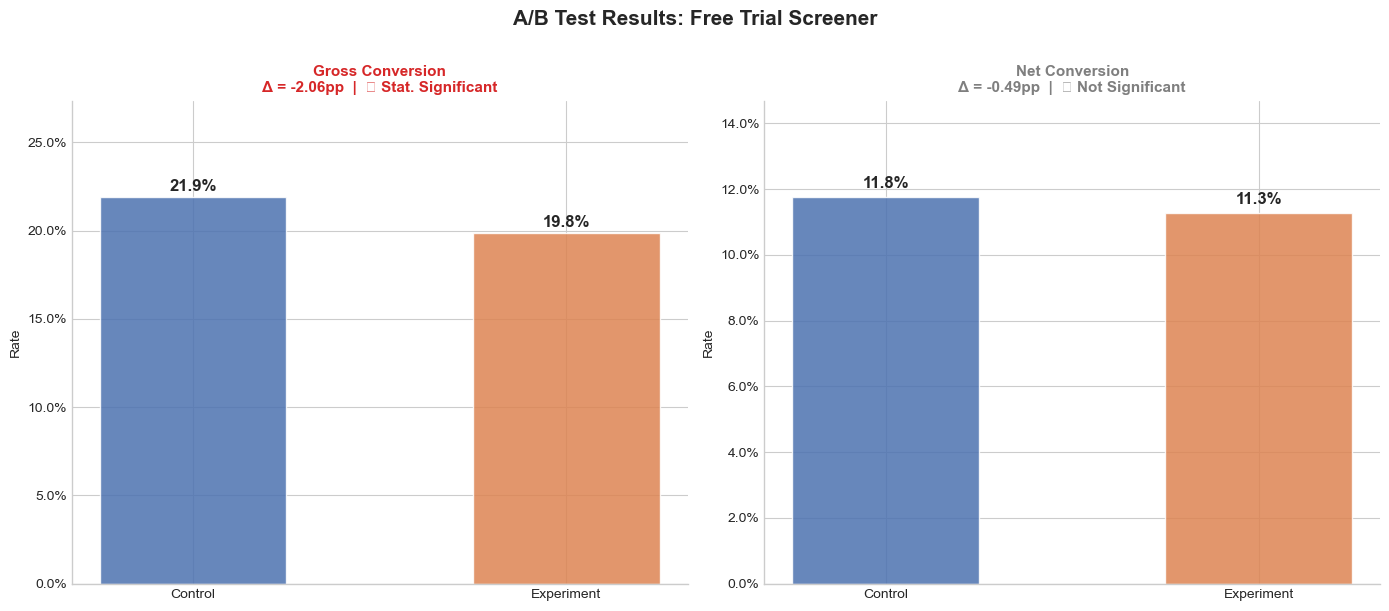

Chart saved.


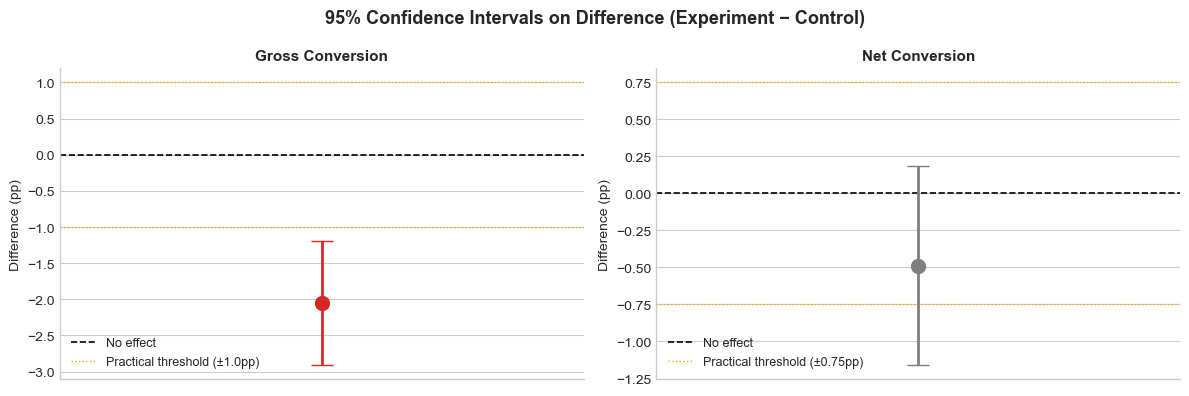

CI chart saved.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('A/B Test Results: Free Trial Screener', fontsize=15, fontweight='bold', y=1.01)

metrics = ['Gross Conversion', 'Net Conversion']
ctrl_rates  = [ctrl_gross, ctrl_net]
exp_rates   = [exp_gross, exp_net]
diffs       = [gross_results[0], net_results[0]]
ci_lows     = [gross_results[1], net_results[1]]
ci_highs    = [gross_results[2], net_results[2]]
d_mins      = [D_MIN_GROSS, D_MIN_NET]
stat_sigs   = [gross_results[3], net_results[3]]

# Chart 1 & 2: Conversion rates side by side + CI on difference
for i, ax in enumerate(axes):
    # Bar chart: control vs experiment rates
    bars = ax.bar(['Control', 'Experiment'], [ctrl_rates[i], exp_rates[i]],
                  color=['#4C72B0', '#DD8452'], width=0.5, alpha=0.85, edgecolor='white')
    
    # Annotate bars
    for bar, rate in zip(bars, [ctrl_rates[i], exp_rates[i]]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{rate:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=12)

    diff_pct = diffs[i] * 100
    sig_label = '✓ Stat. Significant' if stat_sigs[i] else '✗ Not Significant'
    color = '#d62728' if stat_sigs[i] else '#7f7f7f'
    
    ax.set_title(f'{metrics[i]}\nΔ = {diff_pct:+.2f}pp  |  {sig_label}',
                 fontsize=11, color=color, fontweight='bold')
    ax.set_ylabel('Rate', fontsize=10)
    ax.set_ylim(0, max(ctrl_rates[i], exp_rates[i]) * 1.25)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

# Chart 2: Confidence interval on the difference
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))
fig2.suptitle('95% Confidence Intervals on Difference (Experiment − Control)',
              fontsize=13, fontweight='bold')

for i, ax in enumerate(axes2):
    diff  = diffs[i] * 100
    ci_l  = ci_lows[i] * 100
    ci_h  = ci_highs[i] * 100
    d_min = d_mins[i] * 100
    color = '#d62728' if stat_sigs[i] else '#7f7f7f'

    ax.axhline(0, color='black', linewidth=1.2, linestyle='--', label='No effect')
    ax.axhline(-d_min, color='orange', linewidth=1, linestyle=':', label=f'Practical threshold (±{d_min}pp)')
    ax.axhline(d_min,  color='orange', linewidth=1, linestyle=':')

    ax.errorbar(0, diff, yerr=[[diff - ci_l], [ci_h - diff]],
                fmt='o', color=color, markersize=10, capsize=8, linewidth=2)

    ax.set_title(f'{metrics[i]}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Difference (pp)', fontsize=10)
    ax.set_xlim(-0.5, 0.5)
    ax.set_xticks([])
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('confidence_intervals.png', dpi=150, bbox_inches='tight')
plt.show()
print("CI chart saved.")

## 8. Decision & Recommendation

### Summary of results

| Metric | Control | Experiment | Δ | Stat. Sig? | Prac. Sig? |
|--------|---------|------------|---|-----------|-----------|
| Gross Conversion | 21.9% | 19.8% | -2.06pp | ✅ Yes | ✅ Yes |
| Net Conversion | 11.8% | 11.3% | -0.49pp | ❌ No | ❌ No |

### Decision: Do not launch

The screener achieved its filtering goal — enrollment dropped by a statistically and practically significant 2.06 percentage points. But the users who made it through did not pay at a higher rate. Net conversion fell by 0.49pp and the 95% CI [-1.16pp, +0.19pp] cannot rule out a negative impact on revenue.

Launching would reduce enrollment without a compensating gain in payment quality. That is a worse outcome than the baseline.

### What a "launch" verdict would have required
Net conversion to increase by at least 0.75pp (practical significance threshold) with a statistically significant result. Neither condition was met.

### Recommended next steps
1. **Test the message shown to screened-out users.** They were told "consider the free materials" — a better-designed fallback might convert some of them to paid later.
2. **Lower the commitment threshold.** The 5-hour cutoff may be too aggressive. A 3-hour version might filter less while still improving enrollee quality.
3. **Segment by traffic source.** The screener effect may differ between organic, paid, and referral users. A segmented re-run could surface where it works.

In [9]:
from fpdf import FPDF

class PDF(FPDF):
    def header(self):
        self.set_fill_color(30, 70, 130)
        self.rect(0, 0, 210, 18, 'F')
        self.set_font('Helvetica', 'B', 13)
        self.set_text_color(255, 255, 255)
        self.set_xy(10, 4)
        self.cell(0, 10, 'A/B Test Analysis: Free Trial Screener', ln=True)

    def footer(self):
        self.set_y(-12)
        self.set_font('Helvetica', 'I', 8)
        self.set_text_color(150, 150, 150)
        self.cell(0, 10, 'Gnanendra Reddy  |  github.com/gnanendrart  |  linkedin.com/in/gnanendrart', align='C')

pdf = PDF(orientation='P', unit='mm', format='A4')
pdf.add_page()
pdf.set_auto_page_break(auto=False)
pdf.set_margins(14, 22, 14)

def section_title(pdf, text):
    pdf.ln(4)
    pdf.set_font('Helvetica', 'B', 10)
    pdf.set_text_color(30, 70, 130)
    pdf.cell(0, 6, text.upper(), ln=True)
    pdf.set_draw_color(30, 70, 130)
    pdf.set_line_width(0.4)
    pdf.line(14, pdf.get_y(), 196, pdf.get_y())
    pdf.ln(2)
    pdf.set_text_color(40, 40, 40)

def body_text(pdf, text, size=9.5):
    pdf.set_font('Helvetica', '', size)
    pdf.set_text_color(40, 40, 40)
    pdf.multi_cell(0, 5.5, text)

# Context
section_title(pdf, '1. Context')
context = (
    "A SaaS learning platform tested a pre-enrollment screener shown to users after clicking "
    "Start Free Trial. Users who indicated fewer than 5 hours/week of availability were "
    "redirected to free course materials. The control group saw no screener. "
    "The experiment ran for 37 days across ~690,000 pageviews split equally between groups."
)
body_text(pdf, context)

# Hypothesis
section_title(pdf, '2. Hypothesis')
hypothesis = (
    "H0 (null): The screener has no effect on net conversion rate (Payments / Clicks).\n"
    "H1 (alternative): The screener increases net conversion by filtering out low-commitment users.\n\n"
    "Primary metric:   Net Conversion (Payments / Clicks)   practical threshold: +/-0.75pp\n"
    "Guardrail metric: Gross Conversion (Enrollments / Clicks)   practical threshold: +/-1.00pp"
)
body_text(pdf, hypothesis)

# Method
section_title(pdf, '3. Method')
method = (
    "Two-proportion z-test (two-tailed, alpha = 0.05). Metrics computed over the 23 days with "
    "complete enrollment and payment data (~18,000 clicks per group). Sanity checks confirmed "
    "a clean 50/50 traffic split (p = 0.29) and equal click-through rates across groups (p = 0.93), "
    "validating the randomization."
)
body_text(pdf, method)

# Results table
section_title(pdf, '4. Results')

col_w = [52, 28, 32, 22, 24, 26]
headers = ['Metric', 'Control', 'Experiment', 'Delta', 'p-value', 'Decision']
pdf.set_font('Helvetica', 'B', 9)
pdf.set_fill_color(220, 230, 245)
pdf.set_text_color(20, 20, 20)
for w, h in zip(col_w, headers):
    pdf.cell(w, 7, h, border=1, fill=True, align='C')
pdf.ln()

rows = [
    ('Gross Conversion', '21.9%', '19.8%', '-2.06pp', '<0.001', 'Sig. drop'),
    ('Net Conversion',   '11.8%', '11.3%', '-0.49pp', '0.156',  'Not sig.'),
]
colors = [(255, 230, 230), (240, 240, 240)]
text_colors = [(160, 0, 0), (80, 80, 80)]

for row, bg, tc in zip(rows, colors, text_colors):
    pdf.set_font('Helvetica', '', 9)
    pdf.set_fill_color(*bg)
    for w, val in zip(col_w, row):
        pdf.set_text_color(*tc)
        pdf.cell(w, 7, val, border=1, fill=True, align='C')
    pdf.ln()

pdf.ln(1)
pdf.set_font('Helvetica', 'I', 8.5)
pdf.set_text_color(80, 80, 80)
pdf.multi_cell(0, 5, "95% CI Gross Conversion: [-2.91pp, -1.20pp]  |  95% CI Net Conversion: [-1.16pp, +0.19pp]")

# Recommendation
section_title(pdf, '5. Recommendation: Do Not Launch')
rec = (
    "The screener reduced gross enrollment by a statistically and practically significant margin "
    "(-2.06pp, p<0.001), confirming it filtered users as designed. However, net conversion "
    "did not improve (-0.49pp, p=0.156). The confidence interval for net conversion [-1.16pp, +0.19pp] "
    "cannot rule out a negative revenue impact.\n\n"
    "Launching would reduce enrollment without a compensating gain in payment quality "
    "-- a worse expected outcome than the baseline.\n\n"
    "Suggested follow-up experiments:\n"
    "  - Lower the commitment threshold from 5 to 3 hours and re-test.\n"
    "  - Test the messaging shown to screened-out users to recover lost conversions.\n"
    "  - Segment results by traffic source (paid vs organic) to find where the screener may work."
)
body_text(pdf, rec)

pdf.output('ab_test_summary.pdf')
print("PDF saved: ab_test_summary.pdf")

PDF saved: ab_test_summary.pdf
